In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


/tmp
/home/flavia/anaconda3/envs/astroconda/lib/python3.7/site-packages/numpy
/usr/share/zoneinfo
/home/flavia/.config/matplotlib
/home/flavia/anaconda3/envs/astroconda/lib/python3.7/site-packages/matplotlib/mpl-data
/home/flavia/anaconda3/envs/astroconda/lib/python3.7/site-packages/matplotlib/mpl-data
/home/flavia/anaconda3/envs/astroconda/lib/python3.7/site-packages/matplotlib/mpl-data
/home/flavia/anaconda3/envs/astroconda/lib/python3.7/site-packages/matplotlib/mpl-data
/home/flavia/anaconda3/envs/astroconda/lib/python3.7/site-packages/matplotlib/mpl-data
/home/flavia/anaconda3/envs/astroconda/lib/python3.7/site-packages/matplotlib/mpl-data
/home/flavia/anaconda3/envs/astroconda/lib/python3.7/site-packages/matplotlib/mpl-data
/home/flavia/anaconda3/envs/astroconda/lib/python3.7/site-packages/matplotlib/mpl-data
/home/flavia/anaconda3/envs/astroconda/lib/python3.7/site-packages/matplotlib/mpl-data
/home/flavia/anaconda3/envs/astroconda/lib/python3.7/site-packages/matplotlib/mpl-data


/home/flavia/anaconda3/envs/astroconda/lib/python3.7/site-packages/matplotlib/mpl-data
/home/flavia/.config/matplotlib


Checking metadata

In [2]:
md_contaminants = pd.read_csv('../data/qualitat_aire_contaminants.csv')
md_stations = pd.read_csv('../data/2025_qualitat_aire_estacions.csv')
md_stations['Estacio'].unique()

array([ 4, 42, 43, 44, 50, 54, 57, 58])

In [3]:
md_42 = md_stations[md_stations['Estacio'] == 42]
md_42.head()

,Estacio,nom_cabina,codi_dtes,zqa,codi_eoi,Longitud,Latitud,ubicacio,Codi_districte,Nom_districte,Codi_barri,Nom_barri,Clas_1,Clas_2,Codi_Contaminant
4,42,Barcelona - Sants,ID,1,8019042,2.1331,41.3788,Jardins de Can Mantega (Joan Güell - Violant d...,3,Sants-Montjuic,18,Sants,Urbana,Fons,8
5,42,Barcelona - Sants,ID,1,8019042,2.1331,41.3788,Jardins de Can Mantega (Joan Güell - Violant d...,3,Sants-Montjuic,18,Sants,Urbana,Fons,7
6,42,Barcelona - Sants,ID,1,8019042,2.1331,41.3788,Jardins de Can Mantega (Joan Güell - Violant d...,3,Sants-Montjuic,18,Sants,Urbana,Fons,12


The dataset encodes pollutants using numeric identifiers. According to the official metadata provided by Barcelona Open Data, code 8 corresponds to Nitrogen Dioxide (NO2), which was selected for this analysis due to its relevance to urban air quality and health.

Checking dataset

In [4]:
df = pd.read_csv("../data/air_quality.csv")
df.head()

,CODI_PROVINCIA,PROVINCIA,CODI_MUNICIPI,MUNICIPI,ESTACIO,CODI_CONTAMINANT,ANY,MES,DIA,H01,...,H20,V20,H21,V21,H22,V22,H23,V23,H24,V24
0,8,Barcelona,19,Barcelona,43,999,2026,1,18,19.2,...,21.7,V,25.7,V,26.0,V,25.7,V,26.3,V
1,8,Barcelona,19,Barcelona,43,999,2026,1,19,22.6,...,22.4,V,19.2,V,13.7,V,19.1,V,21.0,V
2,8,Barcelona,19,Barcelona,43,999,2026,1,20,24.5,...,21.0,V,18.8,V,20.9,V,19.7,V,22.7,V
3,8,Barcelona,19,Barcelona,43,999,2026,1,21,23.4,...,NaN,N,NaN,N,NaN,N,NaN,N,NaN,N
4,8,Barcelona,19,Barcelona,54,999,2026,1,18,27.0,...,25.4,V,23.6,V,23.6,V,29.8,V,28.0,V


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316 entries, 0 to 315
Data columns (total 57 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CODI_PROVINCIA    316 non-null    int64  
 1   PROVINCIA         316 non-null    object 
 2   CODI_MUNICIPI     316 non-null    int64  
 3   MUNICIPI          316 non-null    object 
 4   ESTACIO           316 non-null    int64  
 5   CODI_CONTAMINANT  316 non-null    int64  
 6   ANY               316 non-null    int64  
 7   MES               316 non-null    int64  
 8   DIA               316 non-null    int64  
 9   H01               312 non-null    float64
 10  V01               316 non-null    object 
 11  H02               312 non-null    float64
 12  V02               316 non-null    object 
 13  H03               312 non-null    float64
 14  V03               316 non-null    object 
 15  H04               312 non-null    float64
 16  V04               316 non-null    object 
 1

,CODI_PROVINCIA,CODI_MUNICIPI,ESTACIO,CODI_CONTAMINANT,ANY,MES,DIA,H01,H02,H03,...,H15,H16,H17,H18,H19,H20,H21,H22,H23,H24
count,316.0,316.0,316.000000,316.000000,316.0,316.0,316.000000,312.000000,312.000000,312.00000,...,311.000000,234.000000,234.000000,234.000000,234.000000,234.000000,234.000000,234.000000,234.000000,234.000000
mean,8.0,19.0,143.430380,180.696203,2026.0,1.0,19.500000,282.107083,278.087532,276.69875,...,298.837428,295.223077,294.901880,298.306880,299.552521,296.590128,291.151068,291.451709,286.824658,285.904359
std,0.0,0.0,265.149383,357.888246,0.0,0.0,1.119807,1001.283850,1001.503853,1001.58492,...,1008.812675,1007.181315,1005.836582,1007.922424,1007.896011,1005.569131,1003.874757,1004.034117,1002.075866,1002.247690
min,8.0,19.0,4.000000,1.000000,2026.0,1.0,18.000000,0.000000,0.000000,-0.02000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.020000,0.000000,0.000000,-0.030000
25%,8.0,19.0,43.000000,8.000000,2026.0,1.0,18.750000,2.112500,2.000000,1.00000,...,2.000000,3.000000,3.000000,3.000000,3.235000,4.000000,2.307500,3.000000,3.000000,3.000000
50%,8.0,19.0,54.000000,11.000000,2026.0,1.0,19.500000,8.300000,6.000000,5.81500,...,13.000000,10.850000,12.000000,12.000000,12.855000,11.005000,12.000000,10.000000,10.000000,9.000000
75%,8.0,19.0,57.000000,107.000000,2026.0,1.0,20.250000,28.325000,32.175000,29.65000,...,38.000000,37.500000,36.750000,37.500000,36.750000,36.000000,27.000000,36.000000,34.250000,32.775000
max,8.0,19.0,881.000000,999.000000,2026.0,1.0,21.000000,4999.000000,4999.000000,4999.00000,...,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000


Identify NO2 and select the relevant column. Identify a station (This case is Barcelona Sants)

In [6]:
df.columns

Index(['CODI_PROVINCIA', 'PROVINCIA', 'CODI_MUNICIPI', 'MUNICIPI', 'ESTACIO',
       'CODI_CONTAMINANT', 'ANY', 'MES', 'DIA', 'H01', 'V01', 'H02', 'V02',
       'H03', 'V03', 'H04', 'V04', 'H05', 'V05', 'H06', 'V06', 'H07', 'V07',
       'H08', 'V08', 'H09', 'V09', 'H10', 'V10', 'H11', 'V11', 'H12', 'V12',
       'H13', 'V13', 'H14', 'V14', 'H15', 'V15', 'H16', 'V16', 'H17', 'V17',
       'H18', 'V18', 'H19', 'V19', 'H20', 'V20', 'H21', 'V21', 'H22', 'V22',
       'H23', 'V23', 'H24', 'V24'],
      dtype='object')

In [7]:
df['CODI_CONTAMINANT'].unique()

array([999,  22,   6, 106, 997, 996, 998,   7, 107,   8, 108,  12, 112,
       995,  14, 114,  11, 111,  10, 110,   9, 109, 901,   1, 101])

In [8]:
df['ESTACIO'].unique()

array([ 43,  54,  57,  50,  44,  58,   4,  42, 881])

In [9]:
df_no2 = df[df['CODI_CONTAMINANT'] == 8]
df_station = df_no2[df_no2['ESTACIO'] == 42]
df_station.head()

,CODI_PROVINCIA,PROVINCIA,CODI_MUNICIPI,MUNICIPI,ESTACIO,CODI_CONTAMINANT,ANY,MES,DIA,H01,...,H20,V20,H21,V21,H22,V22,H23,V23,H24,V24
120,8,Barcelona,19,Barcelona,42,8,2026,1,18,18.0,...,28.0,V,19.0,V,17.0,V,15.0,V,16.0,V
121,8,Barcelona,19,Barcelona,42,8,2026,1,19,18.0,...,25.0,V,22.0,V,17.0,V,11.0,V,8.0,V
122,8,Barcelona,19,Barcelona,42,8,2026,1,20,6.0,...,24.0,V,20.0,V,20.0,V,24.0,V,17.0,V
123,8,Barcelona,19,Barcelona,42,8,2026,1,21,13.0,...,NaN,N,NaN,N,NaN,N,NaN,N,NaN,N


Unpivot hour columns and reshape dataset

In [10]:
value_cols = [f'H{i:02d}' for i in range(1, 25)]

df_long = df_station.melt(
    id_vars=['ANY', 'MES', 'DIA', 'ESTACIO'],
    value_vars=value_cols,
    var_name='hour',
    value_name='NO2'
)

In [11]:
df_long['hour'] = df_long['hour'].str.replace('H', '').astype(int) - 1

In [12]:
df_long['datetime'] = pd.to_datetime(
    dict(
        year=df_long['ANY'],
        month=df_long['MES'],
        day=df_long['DIA'],
        hour=df_long['hour']
    )
)

df_long = df_long[['datetime', 'ESTACIO', 'NO2']]
df_long = df_long.rename(columns={'ESTACIO': 'station'})
df_long = df_long.sort_values('datetime')


Plot NO2 concentration in sants in January

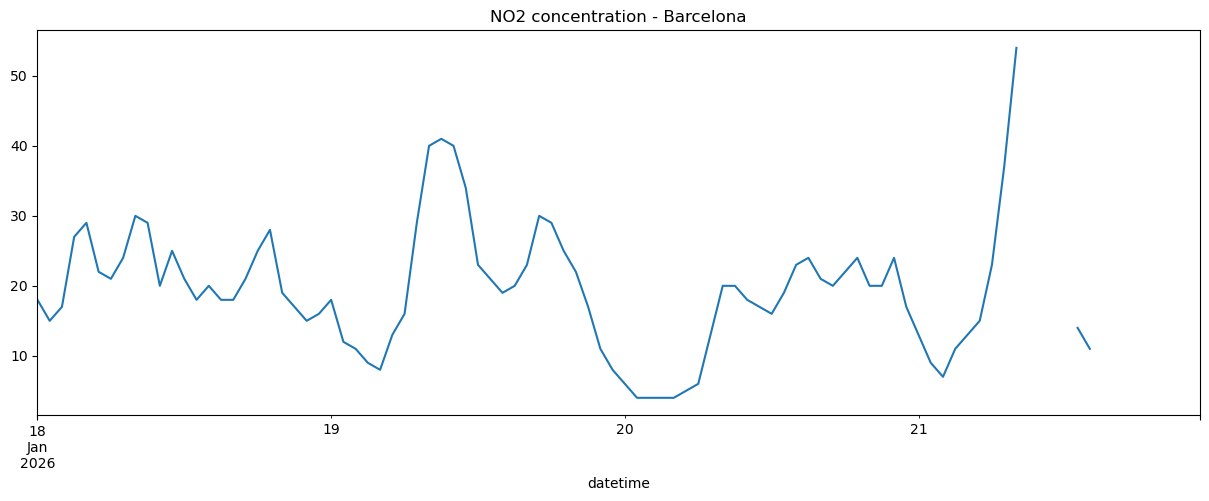

In [14]:
df_long.set_index('datetime')['NO2'].plot(figsize=(15,5))
plt.title("NO2 concentration - Barcelona")
plt.show()